# ML Solubility Prediction Project
## Notebook 01: Data Loading and First Exploration

**Author:** Samson Khunga  
**Date:** 26/03/2026  
**Dataset:** ESOL (Delaney, 2004) --- 1,128 drug-like compounds

### What this notebook does
- Load the ESOL dataset from the internet
- Understand its structure: rows, columns, data types
- Inspect the target variable (log solubility)
- Make a first simple plot
- Save the dataset locally for future use

---

## Section 1: Import Libraries

In [1]:
import pandas as pd        
import numpy as np        
import matplotlib.pyplot as plt  
import seaborn as sns     

%matplotlib inline

# consistent style for all plots in this notebook
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 120   # Higher resolution plots

print("Libraries loaded successfully.")
print(f"  pandas  version: {pd.__version__}")
print(f"  numpy   version: {np.__version__}")
print(f"  seaborn version: {sns.__version__}")

Libraries loaded successfully.
  pandas  version: 3.0.1
  numpy   version: 2.4.3
  seaborn version: 0.13.2


## Section 2: Load the ESOL Dataset

The ESOL dataset (Delaney, 2004) contains 1,128 drug-like molecules
with experimentally measured aqueous solubility values.
We load it directly from the DeepChem GitHub repository.

In [2]:
ESOL_URL = (
    "https://raw.githubusercontent.com/deepchem/"
    "deepchem/master/datasets/delaney-processed.csv"
)

print("Downloading ESOL dataset...")
df = pd.read_csv(ESOL_URL)   # pd.read_csv downloads AND loads it

print("Download complete!")
print(f"\nDataset shape: {df.shape}")

Download complete!

Dataset shape: (1128, 10)


In [3]:
print("=== First 5 rows ===")
print(df.head())

=== First 5 rows ===
  Compound ID  ESOL predicted log solubility in mols per litre  \
0   Amigdalin                                           -0.974   
1    Fenfuram                                           -2.885   
2      citral                                           -2.579   
3      Picene                                           -6.618   
4   Thiophene                                           -2.232   

   Minimum Degree  Molecular Weight  Number of H-Bond Donors  Number of Rings  \
0               1           457.432                        7                3   
1               1           201.225                        1                2   
2               1           152.237                        0                0   
3               2           278.354                        0                5   
4               2            84.143                        0                1   

   Number of Rotatable Bonds  Polar Surface Area  \
0                          7              2

In [4]:
print("=== Column names ===")
for i, col in enumerate(df.columns):
    print(f"  [{i}] {col}")

print(f"\nTotal columns: {len(df.columns)}")

=== Column names ===
  [0] Compound ID
  [1] ESOL predicted log solubility in mols per litre
  [2] Minimum Degree
  [3] Molecular Weight
  [4] Number of H-Bond Donors
  [5] Number of Rings
  [6] Number of Rotatable Bonds
  [7] Polar Surface Area
  [8] measured log solubility in mols per litre
  [9] smiles

Total columns: 10


In [5]:
print("=== Dataset Info ===")
df.info()

# Now checking for missing values explicitly
print("\n=== Missing Values per Column ===")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 10 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Compound ID                                      1128 non-null   str    
 1   ESOL predicted log solubility in mols per litre  1128 non-null   float64
 2   Minimum Degree                                   1128 non-null   int64  
 3   Molecular Weight                                 1128 non-null   float64
 4   Number of H-Bond Donors                          1128 non-null   int64  
 5   Number of Rings                                  1128 non-null   int64  
 6   Number of Rotatable Bonds                        1128 non-null   int64  
 7   Polar Surface Area                               1128 non-null   float64
 8   measured log solubility in mols per litre        1128 non-null   float64
 9   smiles              

In [6]:
print("=== Summary Statistics ===")
print(df.describe().round(3))

=== Summary Statistics ===
       ESOL predicted log solubility in mols per litre  Minimum Degree  \
count                                         1128.000        1128.000   
mean                                            -2.988           1.059   
std                                              1.683           0.239   
min                                             -9.702           0.000   
25%                                             -3.948           1.000   
50%                                             -2.870           1.000   
75%                                             -1.844           1.000   
max                                              1.091           2.000   

       Molecular Weight  Number of H-Bond Donors  Number of Rings  \
count          1128.000                 1128.000         1128.000   
mean            203.937                    0.701            1.391   
std             102.738                    1.090            1.318   
min              16.043       

## Section 3: Visualise the Target Variable

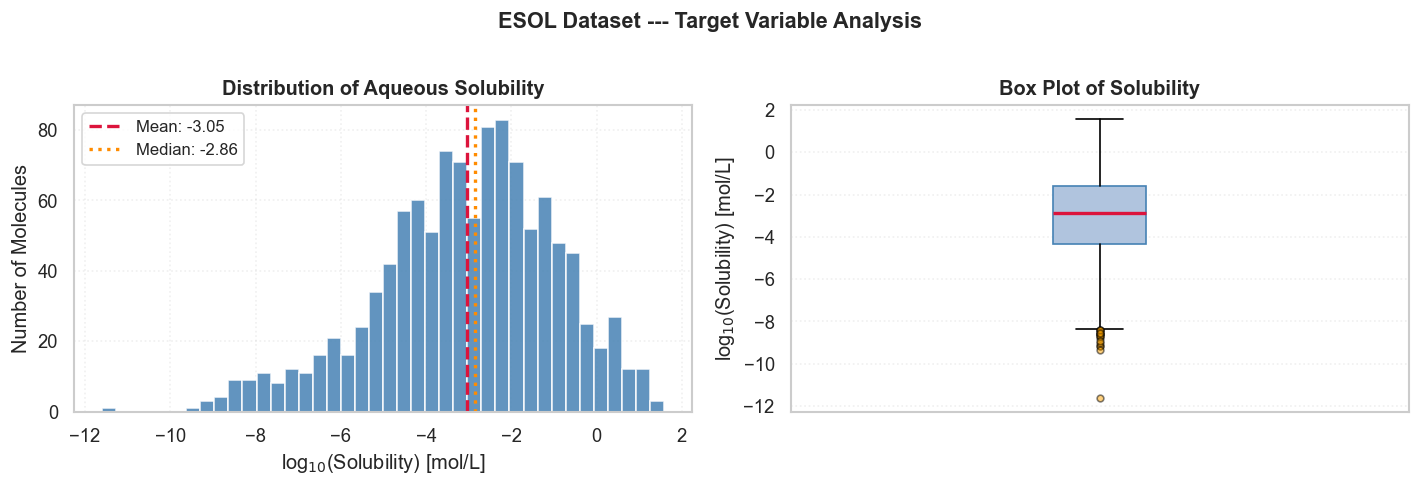

Plot saved to results/01_solubility_distribution.png


In [7]:
target_col = 'measured log solubility in mols per litre'
log_s = df[target_col]

# a figure with two panels side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left panel: histogram ---
axes[0].hist(log_s, bins=40, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].axvline(x=log_s.mean(), color='crimson',
                linewidth=2, linestyle='--',
                label=f'Mean: {log_s.mean():.2f}')
axes[0].axvline(x=log_s.median(), color='darkorange',
                linewidth=2, linestyle=':',
                label=f'Median: {log_s.median():.2f}')
axes[0].set_xlabel('log$_{10}$(Solubility) [mol/L]', fontsize=12)
axes[0].set_ylabel('Number of Molecules', fontsize=12)
axes[0].set_title('Distribution of Aqueous Solubility', fontsize=12,
                  fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle=':')

# --- Right panel: box plot ---
axes[1].boxplot(log_s, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
                medianprops=dict(color='crimson', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='orange',
                                markersize=4, alpha=0.5))
axes[1].set_ylabel('log$_{10}$(Solubility) [mol/L]', fontsize=12)
axes[1].set_title('Box Plot of Solubility', fontsize=12,
                  fontweight='bold')
axes[1].set_xticks([])
axes[1].grid(True, alpha=0.3, linestyle=':')

plt.suptitle('ESOL Dataset --- Target Variable Analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

# Save the figure to the results folder
plt.savefig('../results/01_solubility_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to results/01_solubility_distribution.png")

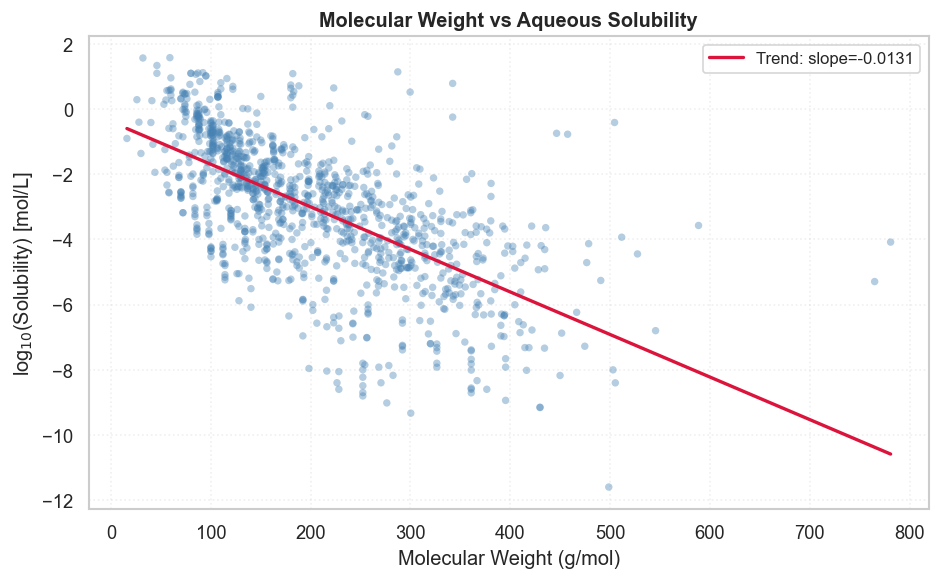

Trend line slope: -0.01306
Interpretation: for every +1 g/mol increase in MW,
  log(S) decreases by 0.01306 units (on average).


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter plot: x = molecular weight, y = log solubility
ax.scatter(df['Molecular Weight'],
           df[target_col],
           alpha=0.4,           # transparency (0=invisible, 1=solid)
           s=20,                # dot size
           color='steelblue',
           edgecolors='none')

ax.set_xlabel('Molecular Weight (g/mol)', fontsize=12)
ax.set_ylabel('log$_{10}$(Solubility) [mol/L]', fontsize=12)
ax.set_title('Molecular Weight vs Aqueous Solubility',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle=':')

# Adding a trend line (linear regression line)
# np.polyfit fits a degree-1 polynomial (a straight line)
x  = df['Molecular Weight'].values
y  = df[target_col].values
coeffs = np.polyfit(x, y, deg=1)   # coeffs[0]=slope, coeffs[1]=intercept
x_line = np.linspace(x.min(), x.max(), 200)
y_line = np.polyval(coeffs, x_line)
ax.plot(x_line, y_line, color='crimson',
        linewidth=2, label=f'Trend: slope={coeffs[0]:.4f}')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../results/02_mw_vs_solubility.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Trend line slope: {coeffs[0]:.5f}")
print("Interpretation: for every +1 g/mol increase in MW,")
print(f"  log(S) decreases by {abs(coeffs[0]):.5f} units (on average).")

In [9]:
save_path = '../data/esol_raw.csv'
df.to_csv(save_path, index=False)

print(f"Dataset saved to: {save_path}")
print(f"File contains {len(df)} rows and {len(df.columns)} columns.")

print("\n=== Day 1 Dataset Summary ===")
print(f"  Dataset        : ESOL (Delaney, 2004)")
print(f"  Molecules      : {len(df)}")
print(f"  Features       : {len(df.columns) - 2} (plus name and target)")
print(f"  Target         : log10(aqueous solubility in mol/L)")
print(f"  Target range   : {df[target_col].min():.2f} "
      f"to {df[target_col].max():.2f}")
print(f"  Target mean    : {df[target_col].mean():.3f}")
print(f"  Missing values : {df.isnull().sum().sum()}")

Dataset saved to: ../data/esol_raw.csv
File contains 1128 rows and 10 columns.

=== Day 1 Dataset Summary ===
  Dataset        : ESOL (Delaney, 2004)
  Molecules      : 1128
  Features       : 8 (plus name and target)
  Target         : log10(aqueous solubility in mol/L)
  Target range   : -11.60 to 1.58
  Target mean    : -3.050
  Missing values : 0
